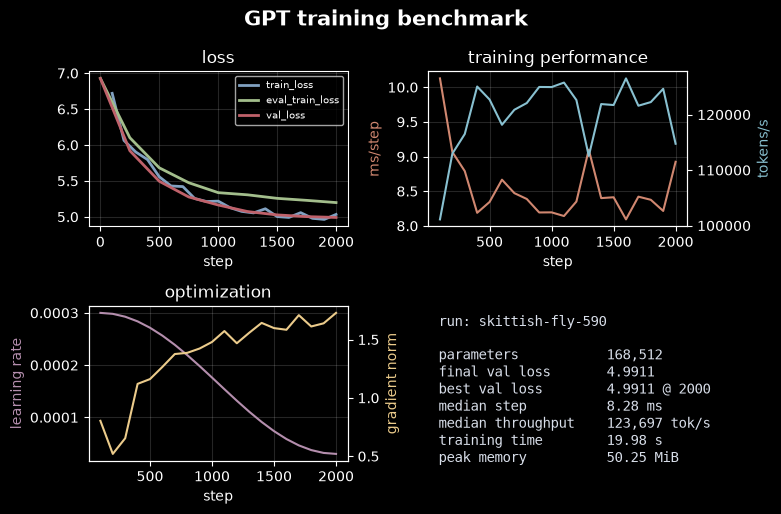

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://localhost:5001")
client = MlflowClient()
experiment = client.get_experiment_by_name("chatbot-training")
run = client.search_runs([experiment.experiment_id], order_by=["start_time DESC"], max_results=1)[0]
metrics, params = run.data.metrics, run.data.params

def history(name):
  points = client.get_metric_history(run.info.run_id, name)
  return [point.step for point in points], [point.value for point in points]

plt.style.use("dark_background")
fig, axes = plt.subplots(2, 2, figsize=(8, 5.2))
fig.patch.set_facecolor("#000000")

for name, color in [("train_loss", "#81a1c1"), ("eval_train_loss", "#a3be8c"), ("val_loss", "#bf616a")]:
  axes[0, 0].plot(*history(name), label=name, color=color, linewidth=2)
axes[0, 0].set_title("loss")
axes[0, 0].legend(fontsize=7)

latency = axes[0, 1]
throughput = latency.twinx()
latency.plot(*history("time_per_step_ms"), color="#d08770", label="ms/step")
throughput.plot(*history("tokens_per_second"), color="#88c0d0", label="tokens/s")
latency.set_title("training performance")
latency.set_ylabel("ms/step", color="#d08770")
throughput.set_ylabel("tokens/s", color="#88c0d0")

learning_rate = axes[1, 0]
gradient_norm = learning_rate.twinx()
learning_rate.plot(*history("learning_rate"), color="#b48ead")
gradient_norm.plot(*history("gradient_norm"), color="#ebcb8b")
learning_rate.set_title("optimization")
learning_rate.set_ylabel("learning rate", color="#b48ead")
gradient_norm.set_ylabel("gradient norm", color="#ebcb8b")

axes[1, 1].axis("off")
summary = (
  f"run: {run.info.run_name}\n\n"
  f"parameters           {int(params['parameter_count']):,}\n"
  f"final val loss       {metrics['final_val_loss']:.4f}\n"
  f"best val loss        {metrics['best_val_loss']:.4f} @ {metrics['best_val_step']:.0f}\n"
  f"median step          {metrics['median_time_per_step_ms']:.2f} ms\n"
  f"median throughput    {metrics['median_tokens_per_second']:,.0f} tok/s\n"
  f"training time        {metrics['total_training_time_ms'] / 1000:.2f} s\n"
  f"peak memory          {metrics['peak_accelerator_memory'] / 2**20:.2f} MiB"
)
axes[1, 1].text(0.04, 0.95, summary, va="top", family="monospace", color="#d8dee9")

for axis in axes.flat[:3]:
  axis.set_xlabel("step")
  axis.grid(alpha=0.15)
fig.suptitle("GPT training benchmark", fontsize=15, fontweight="bold")
fig.tight_layout()
root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "README.md").exists())
fig.savefig(root / "images/training_benchmark.png", dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


In [ ]:
1